<a href="https://colab.research.google.com/github/CrysandyaVic/PBP-Tutor-0/blob/main/Datathon.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [20]:
arr = [3,2,4,1,5]
array2 = [(lambda x : x * 2 if x % 2 == 0 else x*1)(x) for x in arr]
temp = []
for x in arr:
  if(x+1 != arr[arr.index(x)]):
    y = x + 1
    temp.append(y)

gabung = arr + temp
hasil = []
[hasil.append(x) for x in gabung if x not in hasil]

sorted_array = sorted(hasil)
print(sorted_array)

[1, 2, 3, 4, 5, 6]


# New Section

In [21]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [22]:
import pandas as pd
import re
import string
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt

In [23]:
# 1. Load dataset
df = pd.read_csv('/content/drive/My Drive/Datathon 2025/Dataset/al_jazeera.csv')

In [24]:
# 2. Drop baris dengan teks kosong
df = df.dropna(subset=['text']).reset_index(drop=True)

# 3. Fungsi pembersihan teks
def clean_text(text):
    # Hapus bagian “LIVE...” sampai akhir
    text = re.sub(r'\bLIVE.*$', '', text, flags=re.IGNORECASE)
    # Hapus emoji/non-ASCII
    text = re.sub(r'[^\x00-\x7F]+', '', text)
    # Hapus URL
    text = re.sub(r'http\S+|www\.\S+', '', text)
    # Hapus hashtag dan mention
    text = re.sub(r'[@#]\w+', '', text)
    # Hapus tanda baca
    text = text.translate(str.maketrans('', '', string.punctuation))
    # Lowercase & rapikan spasi
    text = text.lower().strip()
    text = re.sub(r'\s+', ' ', text)
    return text

# 4. Terapkan pembersihan
df['cleaned_headline'] = df['text'].apply(clean_text)

In [25]:
# 5. Buat kolom target: total engagement
df['total_engagement'] = df['likes'] + df['comments'] + df['shares']

# 6. Vectorization (Bag-of-Words)
vectorizer = CountVectorizer(
    max_features=1000,
    stop_words='english'
)
X = vectorizer.fit_transform(df['cleaned_headline'])
y = df['total_engagement']

In [26]:
# 7. Latih model Random Forest Regressor
model = RandomForestRegressor(random_state=42, n_estimators=100)
model.fit(X, y)

# 8. Ekstrak feature importances
feature_names = vectorizer.get_feature_names_out()
importances = model.feature_importances_
# Pasangkan dan urutkan dari terbesar
top_n = 20
top_keywords = sorted(
    zip(importances, feature_names),
    reverse=True
)[:top_n]

Top 20 keywords for engagement:
needed: 0.0442
video: 0.0399
palestinian: 0.0321
breaking: 0.0313
gaza: 0.0301
prayers: 0.0255
meals: 0.0229
spent: 0.0214
stop: 0.0204
palestines: 0.0201
thousands: 0.0186
airdropped: 0.0162
session: 0.0151
square: 0.0148
offer: 0.0148
communities: 0.0146
shows: 0.0142
parliamentary: 0.0130
food: 0.0117
israeli: 0.0109


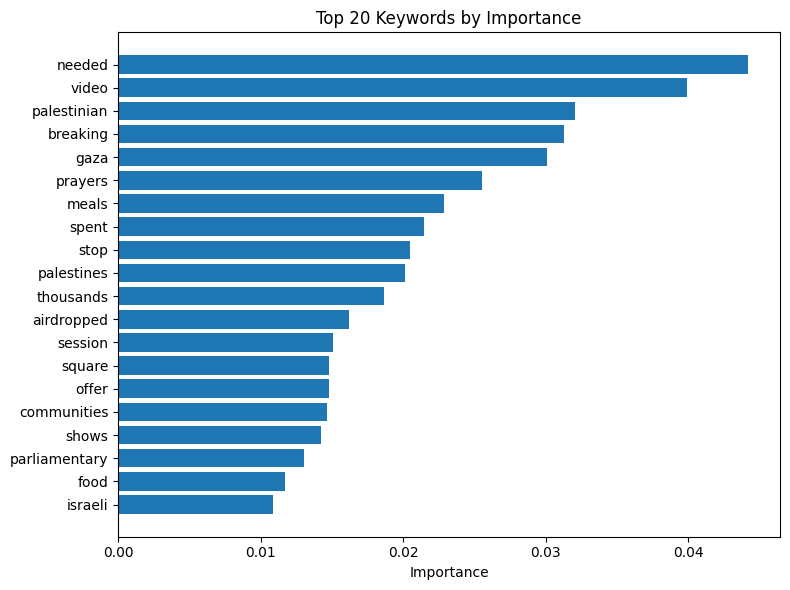

In [27]:
# 9. Tampilkan hasil
print(f"Top {top_n} keywords for engagement:")
for score, word in top_keywords:
    print(f"{word}: {score:.4f}")

# 10. (Opsional) Visualisasi
words = [w for _, w in top_keywords][::-1]
scores = [s for s, _ in top_keywords][::-1]

plt.figure(figsize=(8, 6))
plt.barh(words, scores)
plt.xlabel("Importance")
plt.title(f"Top {top_n} Keywords by Importance")
plt.tight_layout()
plt.show()